***STEP 1.2 — EDA (Exploratory Data Analysis)***

**Analyze Class Distribution**  

Check imbalance → avoid biased model

In [2]:
import os            # file handling (paths, folders)
import glob          # pattern-based file loading
import random        # sampling images

import numpy as np   # numerical operations
import pandas as pd  # tabular analysis (class counts, summaries)

import cv2           # read images + draw bounding boxes
from PIL import Image  # alternative image loading

import matplotlib.pyplot as plt  # plots, image display
import seaborn as sns            # better statistical plots (optional)

from torchvision import datasets, transforms  # classification loading
from torch.utils.data import DataLoader       # batching (optional for EDA)

In [3]:
BASE_DIR = 'smartvision_dataset'
CLASSIFICATION_DIR = os.path.join(BASE_DIR, "classification")

In [4]:
splits = ["train", "val", "test"]

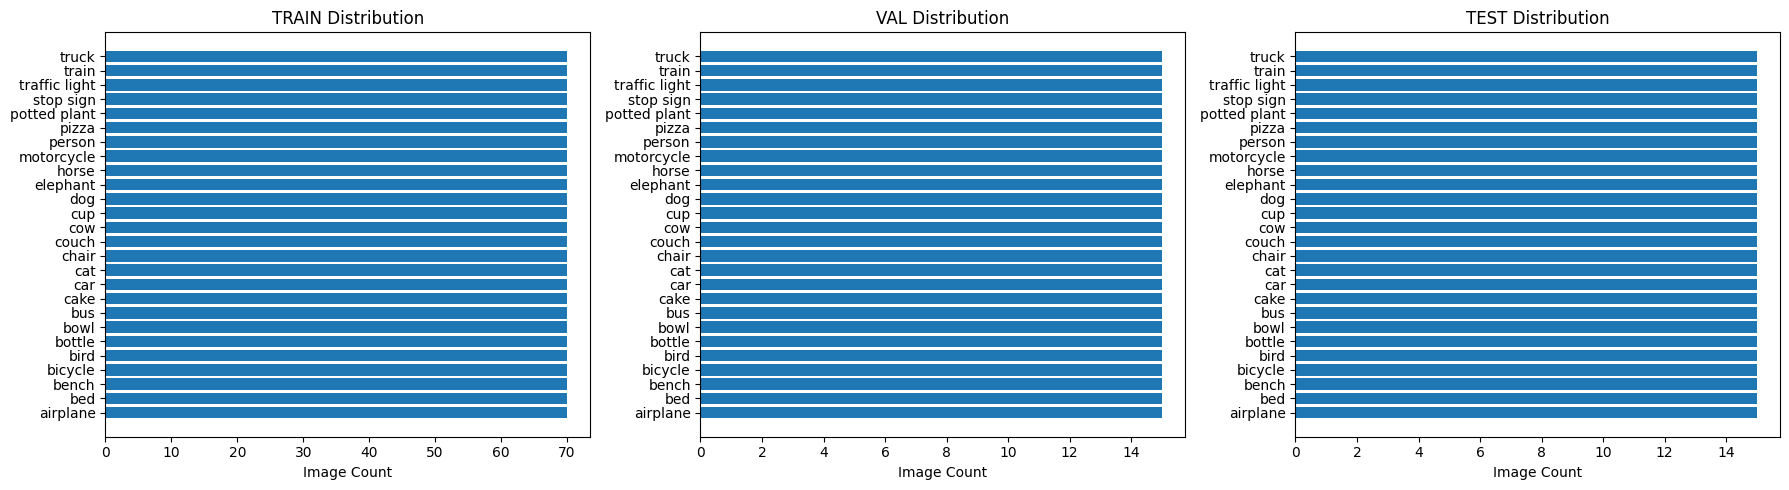

In [5]:
plt.figure(figsize=(18,5))  # one big figure

for idx, split in enumerate(splits):
    dataset_path = os.path.join(CLASSIFICATION_DIR, split)

    class_counts = {}

    for cls in os.listdir(dataset_path):
        class_path = os.path.join(dataset_path, cls)
        if os.path.isdir(class_path):
            class_counts[cls] = len(os.listdir(class_path))

    # Create subplot (1 row, 3 columns)
    plt.subplot(1, 3, idx + 1)

    plt.barh(list(class_counts.keys()), list(class_counts.values()))
    plt.title(f"{split.upper()} Distribution")
    plt.xlabel("Image Count")

plt.tight_layout()
plt.show()

**🔶 2. Image Characteristics (Size, Quality)**

CNN needs fixed size → decide resize strategy

In [6]:
dataset_path = os.path.join(CLASSIFICATION_DIR, split)

sizes = []

for cls in os.listdir(dataset_path):
    for img_name in os.listdir(os.path.join(dataset_path, cls))[:20]:
        img = Image.open(os.path.join(dataset_path, cls, img_name))
        sizes.append(img.size)

print("Sample sizes:", sizes[:5])


Sample sizes: [(224, 224), (224, 224), (224, 224), (224, 224), (224, 224)]


**🔶 3. Objects per Image (Detection)**


🎯 Why?


Understand complexity for YOLO

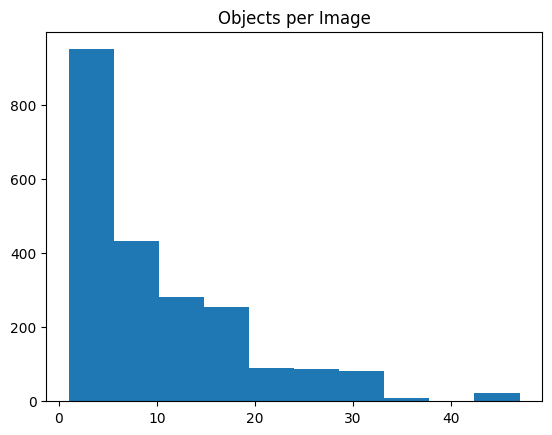

In [7]:
# label_dir = "smartvision_dataset/detection/labels"
DETECTION_IMG_DIR = os.path.join(BASE_DIR, "detection", "images")
DETECTION_LABEL_DIR = os.path.join(BASE_DIR, "detection", "labels")
counts = []

for file in os.listdir(DETECTION_LABEL_DIR):
    with open(os.path.join(DETECTION_LABEL_DIR, file)) as f:
        counts.append(len(f.readlines()))

plt.hist(counts)
plt.title("Objects per Image")
plt.show()

**🔶 4. Visualize Images + Bounding Boxes**

🎯 Why?

Verify annotations are correct

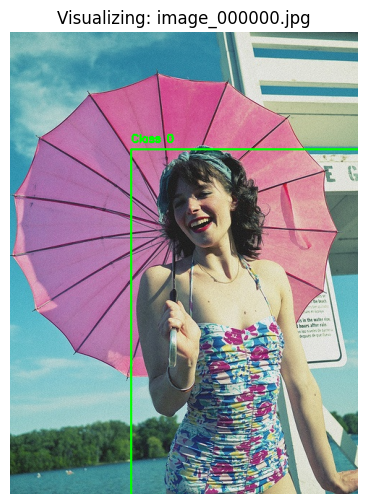

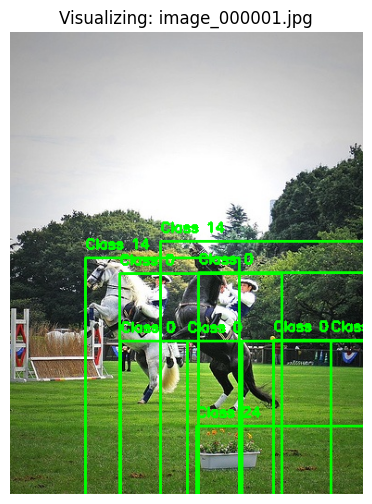

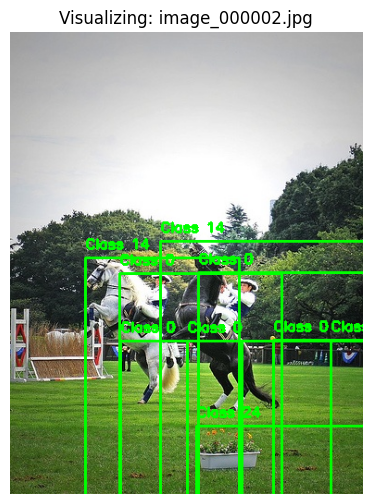

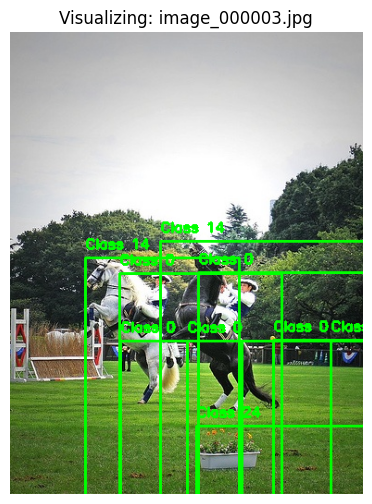

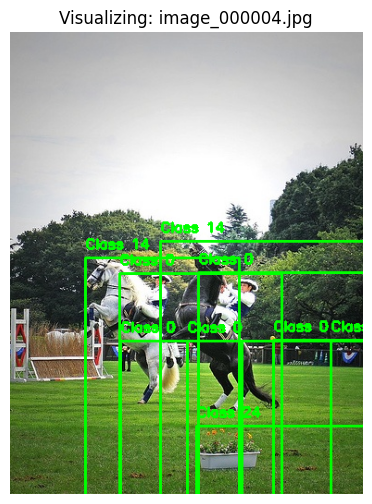

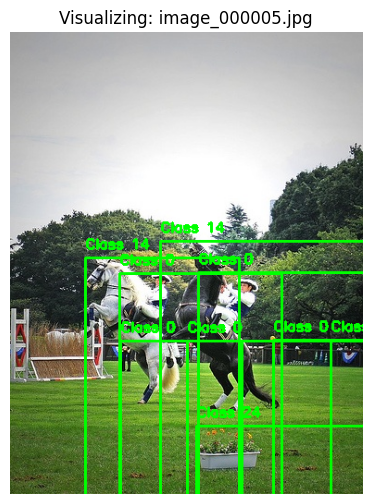

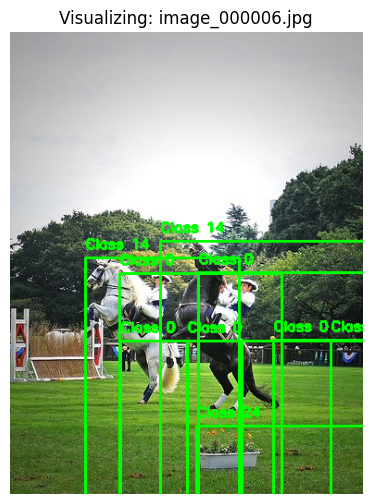

In [10]:
# Indices you want to view
indices_to_view = [0, 1, 2, 3, 4, 5, 6]
all_files = os.listdir(DETECTION_IMG_DIR)

for i in indices_to_view:
    img_file = all_files[i]
    
    # Build paths
    img_path = os.path.join(DETECTION_IMG_DIR, img_file)
    # Using .replace handles the extension, but .split('.') might be safer if you have various formats
    label_file = os.path.splitext(img_file)[0] + ".txt"
    label_path = os.path.join(DETECTION_LABEL_DIR, label_file)

    if not os.path.exists(label_path):
        print(f"Label not found for {img_file}, skipping.")
        continue

    # Load image
    img = cv2.imread(img_path)
    if img is None:
        continue
    h, w, _ = img.shape

    # Read label file (YOLO format: class x_center y_center width height)
    with open(label_path, "r") as f:
        for line in f:
            parts = line.split()
            if len(parts) == 5:
                cls, x, y, bw, bh = map(float, parts)

                # Convert YOLO (normalized 0-1) → pixel coordinates
                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                # Draw bounding box
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, f"Class {int(cls)}", (x1, y1 - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Show image
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Visualizing: {img_file}")
    plt.axis("off")
    plt.show()